# Changing Bases Using Normalizing Flows

Here is a simple demonstration of how a diffeomorphism parameterized by a normalizing flow can transform a basis.

In [2]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import sys
import functools
sys.path.append('..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

Here, we instatiate different normalizing flows that act on the square domain $\Omega = [0, 1]^2$:

In [10]:
%autoreload 2
from basis_learning.diffeomorphisms import UnitCubeNeuralSplineFlow
from basis_learning.diffeomorphisms import UnitSquareKumaraswamy

####
# Toggle between diffeomorphisms here:
# T = UnitCubeNeuralSplineFlow(d=2, hidden_features=64, num_layers=5, num_blocks=2, alpha=0.00005)
T = UnitSquareKumaraswamy(eps=1e-6, a_min=1, b_min=0.5)

T = T.to(device)

You may toggle between any of the above diffeomirphisms. Here is a brief explanation for each of them:
1. The `UnitCubeNeuralSplineFlow` is based on neural spline flows, a flexible diffeomorphism parameterized using spline couplings. Note that spline flows parmeterize diffeomirphisms on $\mathbb{R}^d$, we therefore perform a coordinatewise logit transform first to map values from $[0, 1]^2$ to $\mathbb{R}^d$, apply the neural spline flow, and then perform an inverse logit (sigmoid) to transform everything back to $[0, 1]^2$.

2. The `UnitSquareKumaraswamy` is based on an elementwise Kumaraswamy transform where each coordinate $x$ is mapped to $1 - (1 - x^a)^b$ and $a$ and $b$ are learnable parameters of the transform. This transformation is a diffeomorphism on $[0, 1]^d$ when applied elementwise and is primarily used for debugging purposes as a simple drop-in flow map.

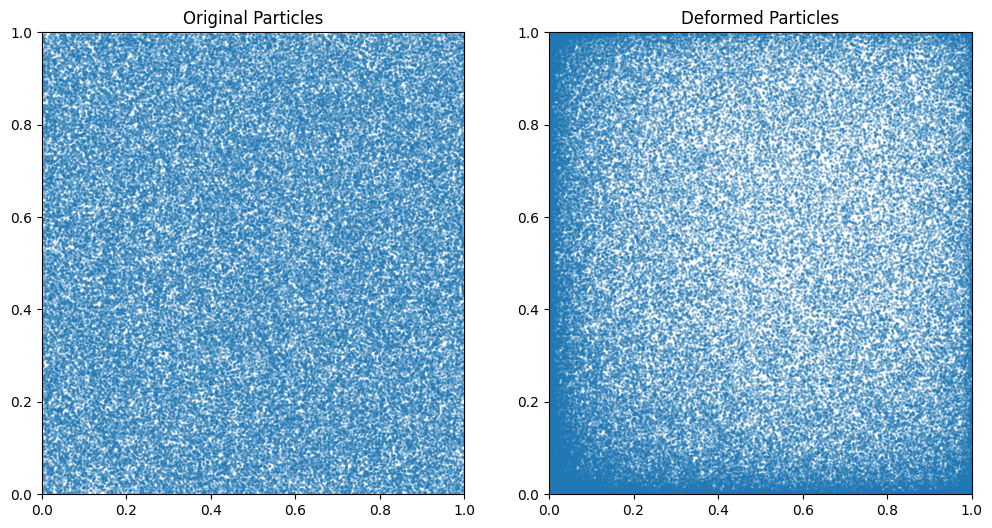

In [11]:
# Sample some points in (0,1)^d
x = torch.rand(8, 2).to(device)
# Forward map and determinant of Jacobian
y, detJ = T.forward(x)
x_rec, detJ_inv = T.inverse(y)

#  check y max and min is in the box
assert (y >= 0).all() and (y <= 1).all(), "Forward map output is out of bounds with values: min {}, max {}".format(y.min().item(), y.max().item())
assert (x - x_rec).abs().max().item() < 1e-6, "Inverse consistency check failed!"
assert (torch.exp(detJ + detJ_inv) - 1).abs().max().item() < 1e-6, "Determinant consistency check failed!"

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
xy = torch.rand(1000_00, 2).to(device)
ax[0].scatter(xy[:,0].detach().cpu(), xy[:,1].detach().cpu(), s=1, alpha=0.3)
ax[0].set_xlim(0,1)
ax[0].set_ylim(0,1)
ax[0].set_title('Original Particles')
transformed_xy, logabsdet = T.forward(xy)
ax[1].scatter(transformed_xy[:,0].detach().cpu(), transformed_xy[:,1].detach().cpu(), s=1, alpha=0.3)
ax[1].set_xlim(0,1)
ax[1].set_ylim(0,1)
ax[1].set_title('Deformed Particles')
plt.show()

Next, deform one of the original bases and see how the heatmap of the inner products changes. Ideally, it should stay the same up to numerical error:

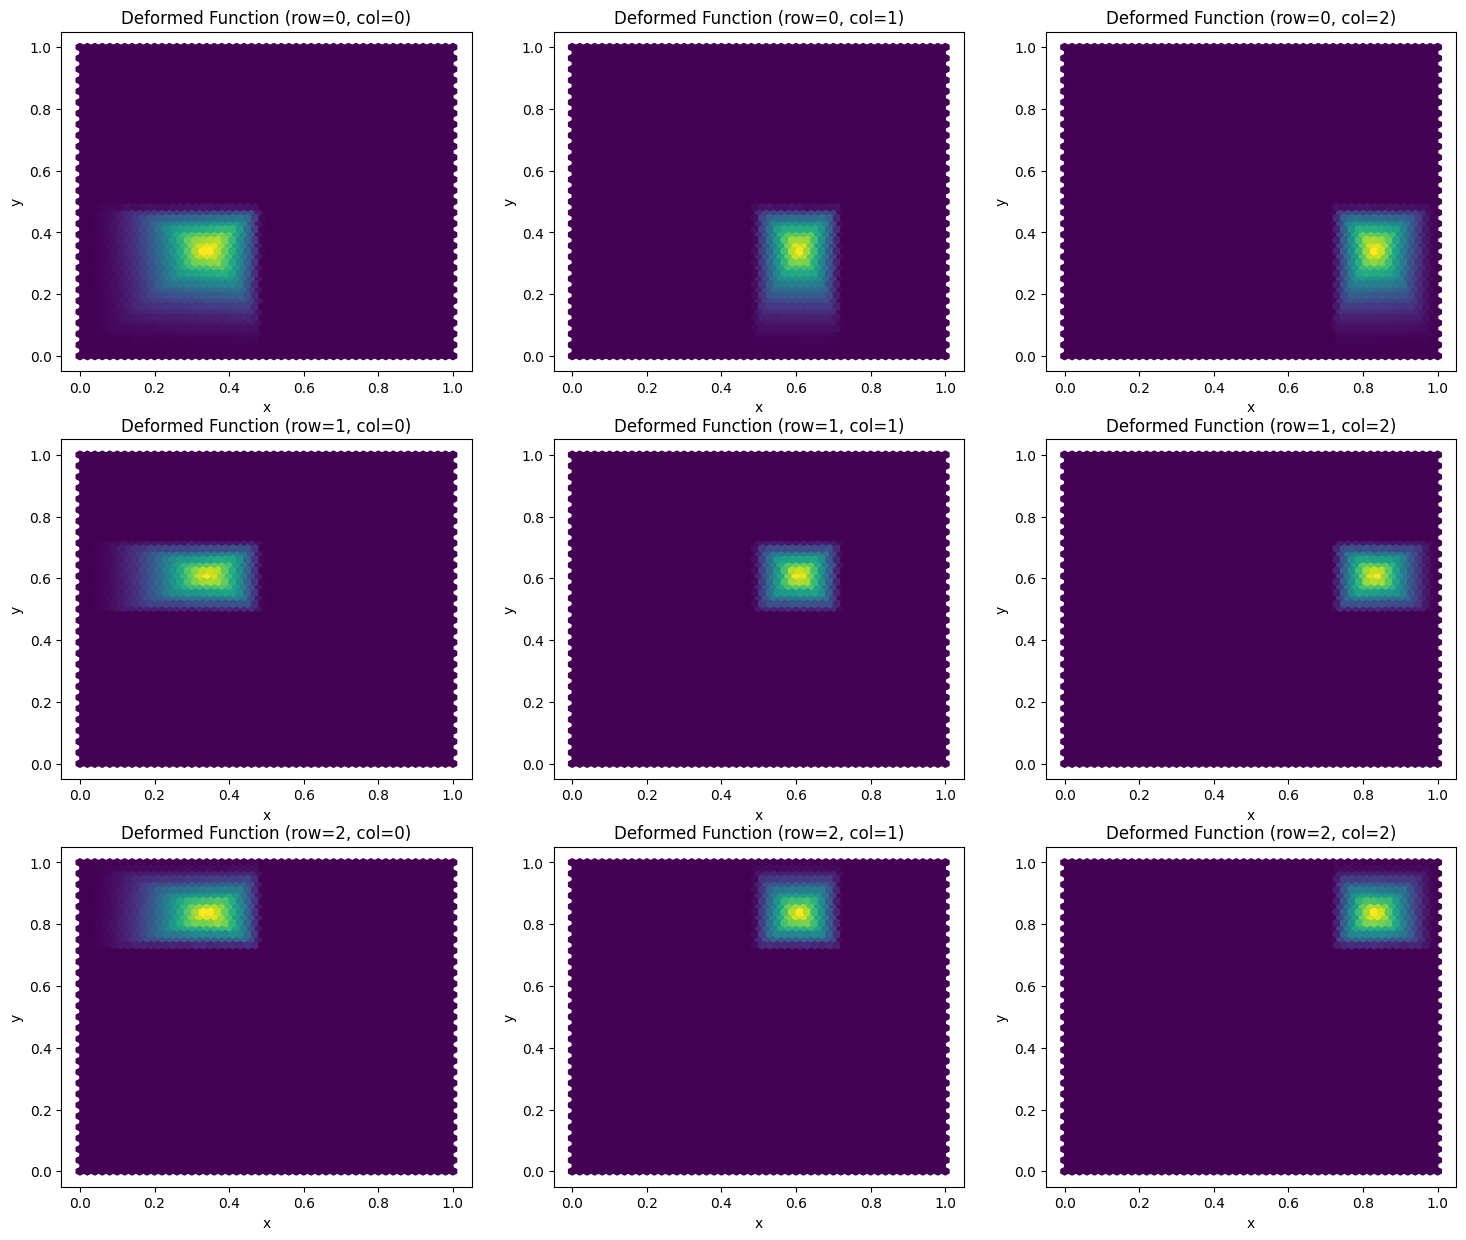

In [12]:
%autoreload 2
from basis_learning.bases import TentBasis
from basis_learning.utils import deform_vals

tent_basis = TentBasis(
    total_cols=3, 
    total_rows=3,
    device=device,
)

all_deformed_vals = []
all_vals = []

fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
N = 100000
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        xy = tent_basis.sample_from_domain(N)
        base_fn = functools.partial(tent_basis, row=row, col=col)
        vals = base_fn(xy)
        all_vals.append(vals.detach().cpu().numpy())
        deformed_vals = deform_vals(xy, T, basis_fn=base_fn)
        deformed_vals = deformed_vals.detach().cpu()
        all_deformed_vals.append(deformed_vals.numpy())

        ax.hexbin(xy[:,0].detach().cpu(), xy[:,1].detach().cpu(), C=deformed_vals, gridsize=50, cmap='viridis') 
        ax.set_title(f'Deformed Function (row={row}, col={col})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()
    

Compute the pairwise inner products and compare them before and after deforming the function:

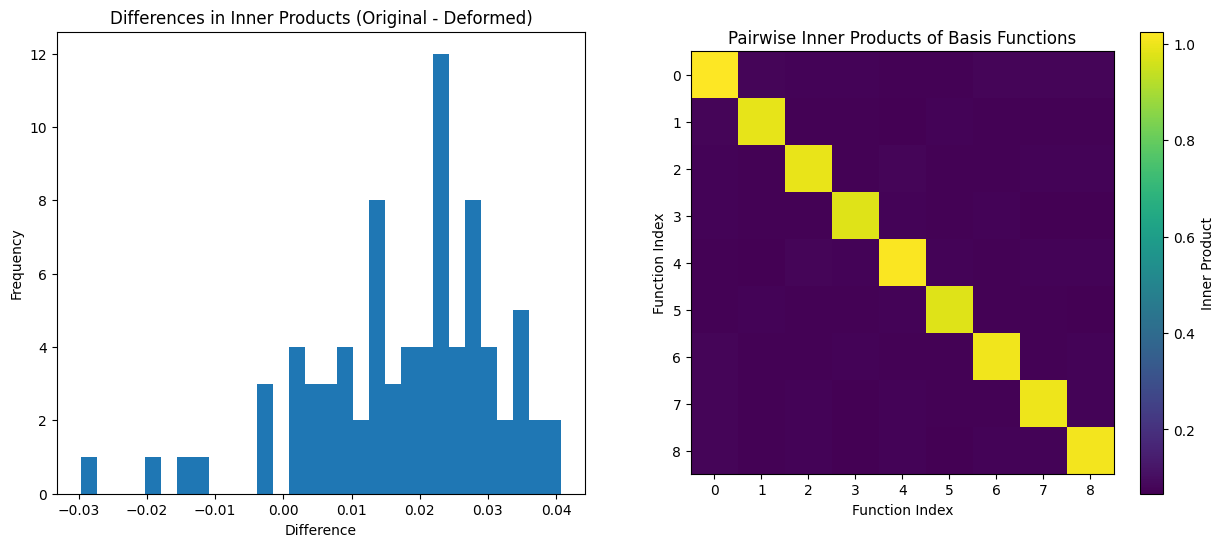

In [13]:
# compute pairwise inner products
inner_products = np.zeros((9, 9))
inner_products_deformed = np.zeros((9, 9))
fig, axes = plt.subplots(figsize=(15, 6), nrows=1, ncols=2)
for i in range(9):
    for j in range(9):
        vi = all_vals[i]
        vj = all_vals[j]
        inner_products[i, j] = (vi * vj).mean().item()
        vi_def = all_deformed_vals[i]
        vj_def = all_deformed_vals[j]
        inner_products_deformed[i, j] = (vi_def * vj_def).mean().item()
# heatmap of inner products
m = axes[1].imshow(inner_products)
# axes[1].
fig.colorbar(m, ax=axes[1], label='Inner Product')
axes[1].set_title('Pairwise Inner Products of Basis Functions')
axes[1].set_xlabel('Function Index')
axes[1].set_ylabel('Function Index')

diffs = inner_products - inner_products_deformed
axes[0].hist(diffs.flatten(), bins=30)
axes[0].set_title('Differences in Inner Products (Original - Deformed)')
axes[0].set_xlabel('Difference')
axes[0].set_ylabel('Frequency')
plt.show()
